In [44]:
import os
from typing import TypedDict, Annotated, List, Optional
from datetime import datetime

from langgraph.graph import StateGraph, END
from langgraph.types import interrupt
from openai import OpenAI

# from dotenv import load_dotenv

# load_dotenv()

# Initialize OpenAI client
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))


In [36]:
from services.doctor_service import get_specialities_list, get_doctor_info, generate_time_slots
from services.booking_service import get_available_slots, confirm_booking

In [37]:
def call_llm(
    system_prompt: str,
    user_prompt: str,
    *,
    model: str = "gpt-4o-mini",
    temperature: float = 0,
    max_tokens: int = 50,
) -> str:
    """
    Centralized helper for all LLM calls.
    Returns the assistant's response
    """
    try:
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ],
            temperature=temperature,
            max_tokens=max_tokens,
        )

        print(f"LLM response: {response.choices[0].message.content.strip()}")
        return response
    except Exception as e:
        print(f"LLM call error: {e}")
        return ""

In [38]:
system_prompt = """Answer this"""

user_prompt = "what is 2+2?"

response = call_llm(system_prompt, user_prompt)

response.choices[0].message.content.strip().lower()

LLM response: 2 + 2 equals 4.


'2 + 2 equals 4.'

In [45]:


class BookingState(TypedDict):
    """State for the booking conversation."""
    messages: Annotated[List[dict], lambda x, y: x + y]
    stage: str  # greeting, select_speciality, select_doctor, select_slot, confirm, completed
    selected_speciality: Optional[str]
    selected_doctor: Optional[dict]
    selected_slot: Optional[str]
    customer_name: Optional[str]
    customer_phone: Optional[str]
    booking_id: Optional[str]
    available_options: List[str]  # For clickable UI options


def create_initial_state():
    """Create initial state for the conversation."""
    return {
        "messages": [],
        "stage": "greeting",
        "selected_speciality": None,
        "selected_doctor": None,
        "selected_slot": None,
        "customer_name": None,
        "customer_phone": None,
        "booking_id": None,
        "available_options": []
    }



def llm_router(state: BookingState) -> str:
    current_stage = state["stage"]
    last_user_msg = state["messages"][-1]["content"] if state["messages"] else ""
    
    # Logic: If the node successfully filled the required field, 
    # we use the LLM to confirm the user wants to proceed.
    
    routing_prompts = {
        "select_speciality": f"""Analyze: "{last_user_msg}"
        Did the user provide a valid speciality? (Currently stored: {state['selected_speciality']})
        Respond ONLY with 'select_doctor' if valid, or 'select_speciality' to ask again.""",
        
        "select_slot": f"""Analyze: "{last_user_msg}"
        Did the user pick a time? (Currently stored: {state['selected_slot']})
        Respond ONLY with 'confirm' if valid, or 'select_slot' to ask again.""",
        
        "confirm": f"""Analyze: "{last_user_msg}"
        Does the user want to 'completed' or 'cancelled' the booking?
        Respond ONLY with the route name."""
    }
    
    if current_stage not in routing_prompts:
        return current_stage

    response = call_llm(
        system_prompt="You are an expert intent router for a clinic chatbot.",
        user_prompt=routing_prompts[current_stage]
    )

    #print(f"LLM response: {response.choices[0].message.content.strip()}"
    route = response.choices[0].message.content.strip().lower()
    
    # Update state stage so the next node knows where it is
    state["stage"] = route
    return route


def greeting_node(state: BookingState) -> BookingState:
    """Greets the user and pauses to see if they want to book."""
    # We ask a question and wait for the response
    user_input = interrupt("👋 Welcome to CarePlus! Would you like to book an appointment?")
    
    # Once resumed, user_input contains their reply
    state["messages"].append({"role": "user", "content": user_input})
    state["stage"] = "select_speciality"
    return state


def select_speciality_node(state: BookingState) -> BookingState:
    """Handle speciality selection."""
    #last_message = state["messages"][-1]["content"] if state["messages"] else ""
    
    # Use LLM to extract speciality
    specialities = get_specialities_list()

    # 1. PAUSE: Show options and wait for raw user input
    raw_user_input = interrupt({
        "role": "assistant",
        "content": "Please choose a speciality:",
        "available_options": specialities
    })
    
    prompt = f"""Extract the medical speciality from this user message: "{raw_user_input}"
    Available specialities: {', '.join(specialities)}
    
    Respond with ONLY the exact speciality name from the list, or "UNKNOWN" if not found.
    """
    
    try:
        response = call_llm(
            system_prompt="You extract information from messages.",
            user_prompt=prompt,
            max_tokens=30
        )
        extracted = response.choices[0].message.content.strip()
  
        
        # Find matching speciality
        selected = None
        for spec in specialities:
            if spec.lower() in extracted.lower() or extracted.lower() in spec.lower():
                selected = spec
                break
        
        if selected:
            state["selected_speciality"] = selected
            state["stage"] = "select_doctor"
            # Log the message to history for context
            state["messages"].append({"role": "user", "content": raw_user_input})
        else:
            state["messages"].append({
                "role": "assistant", 
                "content": f"I'm sorry, I didn't recognize that. Please pick from: {', '.join(specialities)}"
            })
    except Exception as e:
        print(f"Extraction error: {e}")

    
    return state


def select_doctor_node(state: BookingState) -> BookingState:
    """Identify the doctor and move to slot selection."""
    speciality = state["selected_speciality"]
    doctor = get_doctor_info(speciality)
    
    if not doctor:
        state["messages"].append({
            "role": "assistant",
            "content": "Sorry, no doctor available for that speciality. Please try another."
        })
        state["stage"] = "select_speciality"
        return state
    
    # Set the doctor in state and move to the slot stage
    state["selected_doctor"] = doctor
    state["stage"] = "select_slot"
    
    # We do NOT interrupt here because we want the graph to 
    # immediately enter the select_slot_node to ask the first question.
    return state


def select_slot_node(state: BookingState) -> BookingState:
    """Handle time slot selection using interrupt and LLM extraction."""
    doctor = state["selected_doctor"]
    available_slots = generate_time_slots(doctor["office_timing"])
    
    # 1. THE INTERRUPT: Pause and wait for the user's time preference
    message = f"You've selected {doctor['doctor_name']}. Please pick a slot: {', '.join(available_slots)}"
    
    raw_user_input = interrupt({
        "role": "assistant",
        "content": message,
        "available_options": available_slots
    })
    
    # 2. THE EXTRACTION: Use LLM to interpret the raw input
    prompt = f"""Extract the time slot from this user message: "{raw_user_input}"
    Available slots: {', '.join(available_slots)}
    Respond with ONLY the exact time slot from the list, or "UNKNOWN" if not found."""
    
    try:
        response = call_llm(
            system_prompt="You extract time slots from messages.",
            user_prompt=prompt,
            max_tokens=20
        )
        extracted = response.choices[0].message.content.strip()
        
        # Verify if the LLM output matches an actual slot
        selected = next((s for s in available_slots if s.lower() in extracted.lower()), None)
        
        if selected:
            state["selected_slot"] = selected
            #state["stage"] = "confirm"
            #print("current stage:",state["stage"])
            state["messages"].append({"role": "user", "content": raw_user_input})
        else:
            # If invalid, stay in this node. The next loop will hit the interrupt again.
            state["messages"].append({
                "role": "assistant",
                "content": "I didn't catch a valid time. Which slot works for you?"
            })
    except Exception as e:
        print(f"Slot extraction error: {e}")
        
    return state


def confirm_node(state: BookingState) -> BookingState:
    """Handle confirmation stage."""
    doctor = state["selected_doctor"]
    slot = state["selected_slot"]
    
    message = f"""Please review your appointment details:

                **Doctor:** {doctor['doctor_name']}
                **Speciality:** {doctor['speciality']}
                **Time:** Today at {slot}

                Would you like to confirm this appointment?
                Confirm or Cancel?"""

    # --- THE INTERRUPT ---
    # The graph stops here. The value passed to 'resume' later 
    # will be assigned to 'user_choice'.
    user_choice = interrupt(message)

    if user_choice.lower() == "confirm":
        state["stage"] = "completed"
    else:
        state["stage"] = "cancelled"
        
    return state


def completed_node(state: BookingState) -> BookingState:
    """Handle completed booking."""
    doctor = state["selected_doctor"]
    slot = state["selected_slot"]
    
    # Generate a simple booking ID
    booking_id = f"BKG-{datetime.now().strftime('%H%M%S')}"
    
    message = f"""✅ Appointment Confirmed!

**Booking ID:** {booking_id}
**Doctor:** {doctor['doctor_name']}
**Time:** Today at {slot}

Thank you for choosing CarePlus Clinic."""
    
    state["messages"].append({
        "role": "assistant",
        "content": message
    })
    
    state["booking_id"] = booking_id
    state["available_options"] = []
    # We set the stage to 'completed' so the UI knows to stop showing input boxes
    state["stage"] = "completed" 
    
    return state


def cancelled_node(state: BookingState) -> BookingState:
    """Handle cancelled booking."""
    state["messages"].append({
        "role": "assistant",
        "content": "Your appointment has been cancelled. If you'd like to book again, just let me know!"
    })
    
    # In a notebook/Streamlit, you don't necessarily want to jump to greeting 
    # immediately within the same execution loop. 
    # Let the UI handle the "Book Again" trigger.
    state["available_options"] = ["Book Again"]
    state["stage"] = "cancelled" 
    
    return state







In [46]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

def build_booking_graph():
    workflow = StateGraph(BookingState)
    
    # 1. Add Nodes
    workflow.add_node("greeting", greeting_node)
    workflow.add_node("select_speciality", select_speciality_node)
    workflow.add_node("select_doctor", select_doctor_node)
    workflow.add_node("select_slot", select_slot_node)
    workflow.add_node("confirm", confirm_node)
    workflow.add_node("completed", completed_node)
    workflow.add_node("cancelled", cancelled_node)
    
    # 2. Set Entry Point
    workflow.set_entry_point("greeting")
    
    # 3. Add Conditional Edges WITH MAPPING
    # Format: add_conditional_edges(source_node, routing_function, mapping_dict)
    
    # workflow.add_conditional_edges(
    #     "greeting", 
    #     llm_router,
    #     {"greeting": "greeting", "select_speciality": "select_speciality"}
    # )

    workflow.add_edge("greeting", "select_speciality")
    
    workflow.add_conditional_edges(
        "select_speciality", 
        llm_router,
        {"select_speciality": "select_speciality", "select_doctor": "select_doctor"}
    )
    
    # Direct pass from doctor to slot (no router needed here)
    workflow.add_edge("select_doctor", "select_slot") 
    
    workflow.add_conditional_edges(
        "select_slot", 
        llm_router,
        {"select_slot": "select_slot", "confirm": "confirm"}
    )
    
    workflow.add_conditional_edges(
        "confirm", 
        llm_router,
        {"confirm": "confirm", "completed": "completed", "cancelled": "cancelled"}
    )
    
    # 4. Final Edges to END
    workflow.add_edge("completed", END)
    workflow.add_edge("cancelled", END)
    
    # 5. Compile with Checkpointer
    return workflow.compile(checkpointer=MemorySaver())

booking_graph = build_booking_graph()

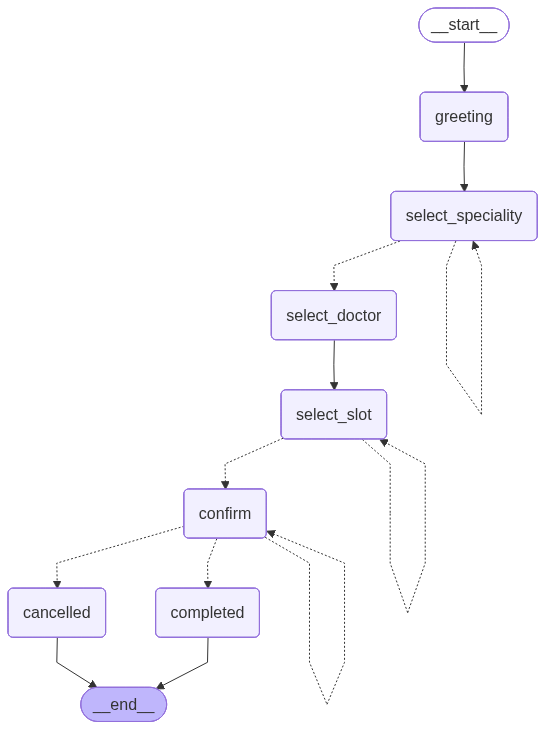

In [47]:
from IPython.display import Image, display

png_bytes = booking_graph.get_graph().draw_mermaid_png()
display(Image(png_bytes))

In [48]:
# Cell 1: Setup
from langgraph.checkpoint.memory import MemorySaver

# Initialize your graph and memory
memory = MemorySaver()
booking_graph = build_booking_graph() # This assumes your graph building function is defined

# Define config globally
config = {"configurable": {"thread_id": "test_new_02"}}

In [49]:
from langgraph.types import Command

def run_booking_session(graph, thread_id="test_session_14"):
    config = {"configurable": {"thread_id": thread_id}}
    print("--- 🏥 Starting CarePlus Booking Session ---")
    
    current_state = graph.get_state(config)


    
    # FIX: Initialize with the FULL state dictionary
    if not current_state.values:
        # This ensures 'selected_speciality', 'selected_doctor', etc., all exist as None
        graph.invoke(create_initial_state(), config=config)

    while True:
        state = graph.get_state(config)

        print(f"Current Stage: {state.values.get('stage')}")
        
        if state.tasks and state.tasks[0].interrupts:
            interrupt_info = state.tasks[0].interrupts[0].value
            
            # Print the AI message clearly
            if isinstance(interrupt_info, dict):
                print(f"\n[AI]: {interrupt_info.get('content', '')}")
                if interrupt_info.get('available_options'):
                    print(f"Options: {', '.join(interrupt_info['available_options'])}")
            else:
                print(f"\n[AI]: {interrupt_info}")
            
            user_input = input("\n[YOU]: ")
            graph.invoke(Command(resume=user_input), config=config)
            
        elif not state.next:
            print("\n--- 🏁 Session Ended ---")
            break
        else:
            graph.invoke(None, config=config)

run_booking_session(booking_graph)

--- 🏥 Starting CarePlus Booking Session ---
Current Stage: greeting

[AI]: 👋 Welcome to CarePlus! Would you like to book an appointment?
Current Stage: select_speciality

[AI]: Please choose a speciality:
Options: General Physician, Dermatologist, Orthopedic, Pediatrician, ENT Specialist
LLM response: General Physician
Current Stage: select_slot

[AI]: You've selected Dr. Anil Sharma. Please pick a slot: 10:00 AM, 11:00 AM, 12:00 PM, 1:00 PM
Options: 10:00 AM, 11:00 AM, 12:00 PM, 1:00 PM
LLM response: 10:00 AM
LLM response: confirm
Current Stage: select_slot

[AI]: Please review your appointment details:

                **Doctor:** Dr. Anil Sharma
                **Speciality:** General Physician
                **Time:** Today at 10:00 AM

                Would you like to confirm this appointment?
                Confirm or Cancel?
Current Stage: completed

--- 🏁 Session Ended ---


In [50]:
# Cell 2: Inspection
current_state = booking_graph.get_state(config)

print("--- Current Stage ---")
print(current_state.values.get("stage"))

print("\n--- Extracted Entities ---")
print(f"Speciality: {current_state.values.get('selected_speciality')}")
print(f"Doctor: {current_state.values.get('selected_doctor')}")
print(f"Slot: {current_state.values.get('selected_slot')}")

print("\n--- Next Steps ---")
print(f"The graph is waiting at: {current_state.next}")

--- Current Stage ---
None

--- Extracted Entities ---
Speciality: None
Doctor: None
Slot: None

--- Next Steps ---
The graph is waiting at: ()
